# Lab 32 — Toward 6G: OTFS and AFDM, Embedded Pilots, Near-Field Beamfocusing, ISAC and RIS

**Companion to Chapter 25** (*The Road to 6G*). Lab 12 gives a first look at OTFS, OFDM radar, RIS and a learned demapper; this lab
goes deeper with the tools of Chapter 25's figure script and `commlib/sixg.py`.
**Time needed:** about 2 hours. **Difficulty:** advanced.

Every generation of mobile radio was built on a few physical ideas that looked exotic ten years earlier. The candidates for 6G
are in that state now: waveforms that live in the delay–Doppler domain so that a 500 km/h train sees a channel as still as a
parked car; arrays so large, at frequencies so high, that users are in the *near field* and beams focus on points instead of
directions; a waveform that is also a radar; and walls that steer waves. This lab builds each one at the scale of a notebook,
reproduces Chapter 25's numbers, and lets you probe where each idea is strong and where it is fragile.

### What you will learn
1. Describe a doubly dispersive channel in the time–frequency and delay–Doppler domains, and size an OTFS grid.
2. Compare OFDM (one-tap and ICI-aware), OTFS and AFDM with LMMSE detection under fractional Doppler.
3. Estimate an OTFS channel from a single embedded pilot with a guard region, and see what fractional Doppler costs.
4. Focus a large array on a point in its near field, and measure the depth of focus against the Rayleigh distance.
5. Build an OFDM ISAC range–Doppler processor and see how the data constellation sets its sidelobe floor.
6. Size a reconfigurable intelligent surface with the product-distance law and phase quantisation.

### Prerequisites
Lab 7 and Lab 28 (OFDM, ICI, OFDM radar), Lab 29 (arrays), Lab 12. Chapter 25.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | The delay–Doppler channel and OTFS grid sizing | yes |
| 2 | OFDM vs OTFS vs AFDM under Doppler | yes |
| 3 | OTFS embedded-pilot channel estimation | yes |
| 4 | Near-field beamfocusing | yes |
| 5 | ISAC: range–Doppler maps and the constellation trade-off | yes |
| 6 | RIS: the N² law and the product distance | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import sixg
from commlib import labkit as lk

rng = lk.setup(seed=32, lab="32")
C0 = sixg.C0
QPSK = cl.get_constellation("qpsk")
cn = lambda r, shape: (r.standard_normal(shape) + 1j * r.standard_normal(shape)) / np.sqrt(2)

Lab 32 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 32


## 1. The delay–Doppler channel and OTFS grid sizing

A channel of $P$ paths, path $p$ with delay $\ell_p$ and Doppler $\nu_p$, multiplies a time signal by
$\sum_p h_p e^{j2\pi\nu_p n}s[n-\ell_p]$. In the time–frequency grid that OFDM uses, the response $H[k, n]$ fluctuates in both
directions; in the **delay–Doppler** (DD) grid it is a handful of fixed points $(\ell_p, \nu_p)$ that change only as the geometry
changes. **OTFS** places data symbols on an $M \times N$ DD grid (delay resolution $1/(M\Delta f)$, Doppler resolution $1/(NT)$),
maps them to the time–frequency grid with the inverse symplectic FFT and transmits with OFDM. Chapter 25 sizes a grid for a 500 km/h
train at 4 GHz: $\nu_{\max} = 1852$ Hz, a 5 µs delay spread, $M = 512$ at 30 kHz, $N = 64$.

### Interactive: the grid and the train

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

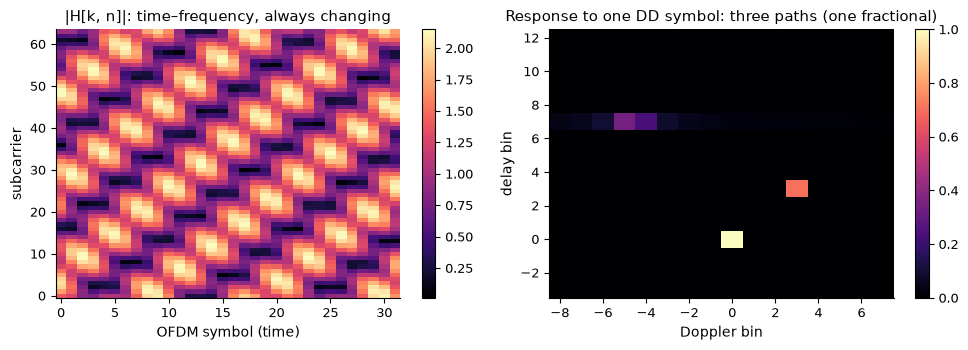

500 km/h at 4 GHz,
maximum Doppler ν_max,1853 Hz
OFDM ν_max·T and signal-to-ICI,"0.062, 19.0 dB"
delay resolution 1/(MΔf),65 ns → ℓ_max ≈ 77 bins
Doppler resolution 1/(NT),469 Hz → k_max ≈ 4.0 bins
frame duration NT,2.13 ms
embedded-pilot guard (2ℓ+1)(4k+1),2635 bins = 8.0% of the frame


In [3]:
def dd_demo(speed_kmh=500.0, fc_ghz=4.0, scs_khz=30.0, M=512, N=64, tau_us=5.0):
    Mg, Ng = 64, 32
    MN = Mg * Ng
    l = np.array([0, 3, 7]); nu = np.array([0.0, 3.0, -4.6]) / MN; h = np.array([1.0, 0.7, 0.45]) * np.exp(1j * np.array([0, 1.3, 2.4]))
    n_sym = np.arange(Ng)[None, :] * Mg + Mg / 2; k = np.arange(Mg)[:, None]
    Htf = sum(hp * np.exp(2j * np.pi * vp * n_sym) * np.exp(-2j * np.pi * k * lp / Mg) for lp, vp, hp in zip(l, nu, h))
    X = np.zeros((Mg, Ng), complex); X[0, 0] = 1
    Y = sixg.otfs_demodulate(sixg.dd_channel_matrix(l, nu, h, MN) @ sixg.otfs_modulate(X), Mg, Ng)
    fig, ax = lk.fig("row2", 1, 2)
    im = ax[0].imshow(np.abs(Htf), origin="lower", aspect="auto", cmap="magma"); ax[0].grid(False); plt.colorbar(im, ax=ax[0])
    ax[0].set_xlabel("OFDM symbol (time)"); ax[0].set_ylabel("subcarrier"); ax[0].set_title("|H[k, n]|: time–frequency, always changing")
    Ys = np.roll(np.roll(np.abs(Y), Mg // 4, axis=0), Ng // 2, axis=1)
    im = ax[1].imshow(Ys, origin="lower", aspect="auto", cmap="magma", extent=[-Ng // 2 - 0.5, Ng // 2 - 0.5, -Mg // 4 - 0.5, 3 * Mg // 4 - 0.5])
    ax[1].set_xlim(-8.5, 7.5); ax[1].set_ylim(-3.5, 12.5); ax[1].grid(False); plt.colorbar(im, ax=ax[1])
    ax[1].set_xlabel("Doppler bin"); ax[1].set_ylabel("delay bin"); ax[1].set_title("Response to one DD symbol: three paths (one fractional)")
    lk.show(fig)
    v = speed_kmh / 3.6
    numax = v * fc_ghz * 1e9 / C0
    T = 1 / (scs_khz * 1e3)
    lmax = tau_us * 1e-6 * M * scs_khz * 1e3
    kmax = numax * N * T
    lk.table([["maximum Doppler ν_max", f"{numax:.0f} Hz"], ["OFDM ν_max·T and signal-to-ICI", f"{numax * T:.3f}, {-lk.db((np.pi * numax * T) ** 2 / 3):.1f} dB"],
              ["delay resolution 1/(MΔf)", f"{1e9 / (M * scs_khz * 1e3):.0f} ns → ℓ_max ≈ {lmax:.0f} bins"],
              ["Doppler resolution 1/(NT)", f"{1 / (N * T):.0f} Hz → k_max ≈ {kmax:.1f} bins"],
              ["frame duration NT", f"{N * T * 1e3:.2f} ms"],
              ["embedded-pilot guard (2ℓ+1)(4k+1)", f"{(2 * round(lmax) + 1) * (4 * np.ceil(kmax) + 1):.0f} bins = {100 * (2 * round(lmax) + 1) * (4 * np.ceil(kmax) + 1) / (M * N):.1f}% of the frame"]],
             [f"{speed_kmh:g} km/h at {fc_ghz:g} GHz", ""])

lk.interact(dd_demo, speed_kmh=lk.slider(500, 0, 1000, 10, "speed (km/h)"), fc_ghz=lk.slider(4, 0.7, 30, 0.1, "carrier (GHz)"),
            scs_khz=lk.choice([15.0, 30.0, 60.0, 120.0], 30.0, "subcarrier spacing (kHz)"), M=lk.choice([128, 256, 512, 1024], 512, "M"),
            N=lk.choice([16, 32, 64, 128], 64, "N"), tau_us=lk.slider(5, 0.5, 10, 0.5, "delay spread (µs)"))

**What you should see.** The time–frequency response is a moving interference pattern; the DD response is three spots, the
fractional-Doppler one smeared along the Doppler axis. The table reproduces Chapter 25: 1852 Hz, $\nu_{\max}T = 0.062$ and about
19 dB of signal-to-ICI for OFDM, 65 ns and 469 Hz resolutions, $\ell_{\max} \approx 77$ and $k_{\max} \approx 4$ bins, a 2.13 ms
frame, and an embedded-pilot guard of about 8% of the frame.

### Try it yourself 1.1
What is the Doppler resolution (Hz) of an OTFS frame of $N = 32$ symbols at 120 kHz subcarrier spacing (ignore the cyclic prefix)?

In [5]:
answer_1_1 = None
lk.check("1.1 Doppler resolution (Hz)", answer_1_1, 120e3 / 32, atol=1)

[TODO] 1.1 Doppler resolution (Hz): not attempted yet: replace the None with your answer

## 2. OFDM vs OTFS vs AFDM under Doppler

On a $16 \times 16$ block (256 samples) with four paths, delays up to 3 samples and fractional Doppler up to $\nu_{\max}$, compare:
OFDM with a one-tap equaliser (ignores ICI); OFDM with an ICI-aware LMMSE equaliser per symbol; OTFS with block LMMSE; and **AFDM**
(chirp subcarriers via the discrete affine Fourier transform, chirp rate $c_1$ matched to the maximum Doppler) with block LMMSE.
This is Chapter 25's Figure 25-*otfs-ber* at a smaller Monte Carlo size.

### Interactive: maximum Doppler

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

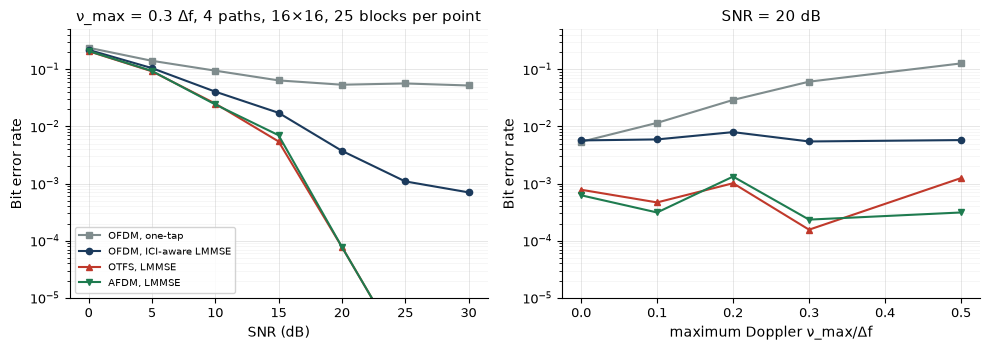

scheme,10 dB,20 dB,30 dB
"OFDM, one-tap",9.5e-02,5.4e-02,5.2e-02
"OFDM, ICI-aware LMMSE",4.1e-02,3.7e-03,7.0e-04
"OTFS, LMMSE",2.5e-02,7.8e-05,0.0e+00
"AFDM, LMMSE",2.4e-02,7.8e-05,0.0e+00


In [7]:
def ofdm_sim(M, N, cp, l, nu, h, x, n0, r, ici_aware):
    X = x.reshape(N, M)
    s = np.concatenate([np.fft.ifft(X, axis=1)[:, -cp:] * np.sqrt(M), np.fft.ifft(X, axis=1) * np.sqrt(M)], axis=1).ravel()
    rr = sixg.apply_dd_channel(s, l, nu, h) + np.sqrt(n0) * cn(r, len(s))
    Y = np.fft.fft(rr.reshape(N, M + cp)[:, cp:], axis=1) / np.sqrt(M)
    F = sixg.dft_matrix(M); eye = np.eye(M); out = np.empty((N, M), complex)
    for i in range(N):
        n0i = i * (M + cp) + cp
        Ht = sum(hp * np.exp(2j * np.pi * vp * (n0i + np.arange(M)))[:, None] * np.roll(eye, int(lp), axis=0) for lp, vp, hp in zip(l, nu, h))
        G = F @ Ht @ F.conj().T
        out[i] = sixg.lmmse(G, Y[i], n0) if ici_aware else Y[i] / np.diag(G)
    return out.ravel()

def ber_point(snr_db, nu_max, trials, r, M=16, N=16, P=4, lmax=3):
    MN = M * N; n0 = lk.undb(-snr_db)
    A_otfs = sixg.otfs_matrix(M, N)
    alpha = int(np.ceil(nu_max * MN))
    A_afdm = sixg.afdm_matrix(MN, sixg.afdm_c1(MN, alpha, guard=1), c2=1 / (MN ** 2 * np.pi))
    errs = dict(ofdm1=0, ofdmL=0, otfs=0, afdm=0); nb = 0
    for _ in range(trials):
        l, nu, h = sixg.random_dd_paths(P, lmax, nu_max, r)
        b = cl.random_bits(2 * MN, r); x = QPSK.modulate(b); nb += len(b)
        for key, ici in [("ofdm1", False), ("ofdmL", True)]:
            errs[key] += np.sum(QPSK.demodulate(ofdm_sim(M, N, lmax + 1, l, nu, h, x, n0, r, ici)) != b)
        Ht = sixg.dd_channel_matrix(l, nu, h, MN)
        w = np.sqrt(n0) * cn(r, MN)
        for key, A in [("otfs", A_otfs), ("afdm", A_afdm.conj().T)]:
            He = A.conj().T @ Ht @ A
            errs[key] += np.sum(QPSK.demodulate(sixg.lmmse(He, He @ x + A.conj().T @ w, n0)) != b)
    return {k_: v / nb for k_, v in errs.items()}

LAB = {"ofdm1": ("OFDM, one-tap", lk.GRAY, "s"), "ofdmL": ("OFDM, ICI-aware LMMSE", lk.NAVY, "o"), "otfs": ("OTFS, LMMSE", lk.RED, "^"), "afdm": ("AFDM, LMMSE", lk.GREEN, "v")}

def wave_demo(nu_max_sc=0.3, trials=25):
    r = np.random.default_rng(25)
    snrs = np.arange(0, 31, 5.0)
    res = [ber_point(s_, nu_max_sc / 16, trials, r) for s_ in snrs]
    dop = np.array([0.0, 0.1, 0.2, 0.3, 0.5])
    res2 = [ber_point(20.0, d / 16, trials, r) for d in dop]
    fig, ax = lk.fig("row2", 1, 2)
    for k_, (lab, col, mk) in LAB.items():
        ax[0].semilogy(snrs, [max(x[k_], 1e-6) for x in res], marker=mk, color=col, label=lab)
        ax[1].semilogy(dop, [max(x[k_], 1e-6) for x in res2], marker=mk, color=col, label=lab)
    lk.ber_axes(ax[0], xlabel="SNR (dB)", ylim=(1e-5, 0.5)); ax[0].legend(fontsize=7.5)
    ax[0].set_title(f"ν_max = {nu_max_sc:g} Δf, 4 paths, 16×16, {trials} blocks per point")
    lk.ber_axes(ax[1], xlabel="maximum Doppler ν_max/Δf", ylim=(1e-5, 0.5)); ax[1].set_title("SNR = 20 dB")
    lk.show(fig)
    lk.table([[LAB[k_][0]] + [f"{x[k_]:.1e}" for x in res[2::2]] for k_ in LAB], ["scheme"] + [f"{s_:g} dB" for s_ in snrs[2::2]])

lk.interact(wave_demo, nu_max_sc=lk.slider(0.3, 0.0, 0.5, 0.05, "max Doppler (subcarrier spacings)"), trials=lk.choice([10, 25, 100, 400], 25, "blocks per point"))

**What you should see.** The one-tap OFDM receiver hits an error floor set by ICI; an ICI-aware LMMSE receiver removes most of it;
OTFS and AFDM with block LMMSE do better still at high SNR because each symbol is spread over the whole time–frequency block and
collects the full diversity of the four paths (their curves are steeper). OTFS and AFDM perform almost identically, as Chapter 25
says: the differences lie in pilots, complexity and compatibility. At $\nu_{\max} = 0$ all LMMSE receivers coincide in spirit,
and OFDM loses only its lack of diversity.

## 3. OTFS embedded-pilot channel estimation

Because the DD channel is sparse, OTFS can estimate it from **one pilot** in the DD grid surrounded by a guard region of empty bins
(Raviteja, Phan and Hong): the received guard region *is* the channel's DD response. Here the pilot sits in delay row
$\ell_p = M/2$ and the guard spans rows $\ell_p \pm \ell_{\max}$ across all Doppler bins (overhead $(2\ell_{\max}+1)/M$). The receiver
thresholds the guard region, keeps the significant (delay, Doppler-bin) taps, fits their gains by least squares, rebuilds the effective
channel, cancels the pilot and detects the data with LMMSE. With **integer** Doppler the on-grid model is exact; **fractional** Doppler
leaks energy across Doppler bins and the on-grid estimate leaves an error floor.

### Interactive: pilot power and fractional Doppler

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

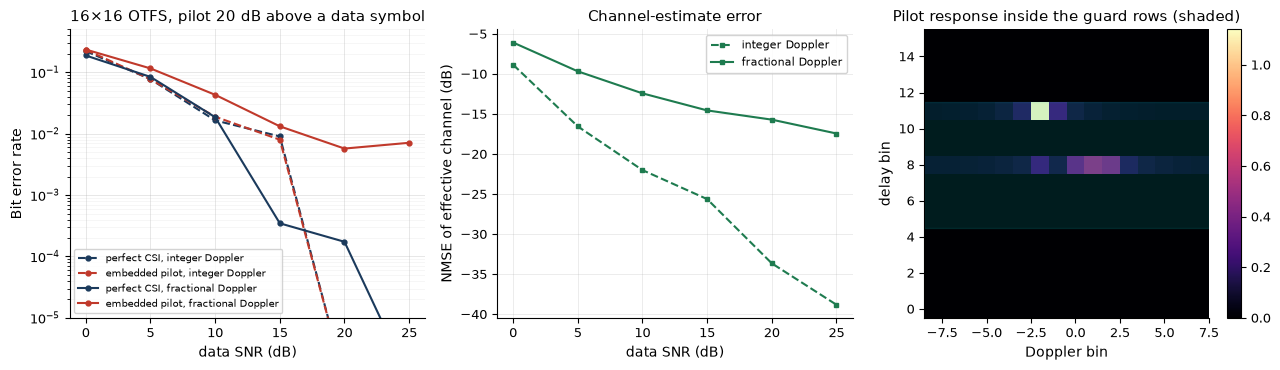

,
guard overhead (2ℓmax+1)/M,44% of the grid
data symbols per frame,144


In [9]:
Mp, Np, LMAX = 16, 16, 3
MNp = Mp * Np
A_P = sixg.otfs_matrix(Mp, Np)
lp_row = Mp // 2
guard = np.zeros((Mp, Np), bool); guard[lp_row - LMAX:lp_row + LMAX + 1, :] = True
data_idx = np.flatnonzero(~guard.ravel(order="F"))
pil_idx = lp_row + Mp * 0                                     # pilot at (delay lp_row, Doppler bin 0)
CAND = [(l_, k_) for l_ in range(LMAX + 1) for k_ in range(-4, 5)]
RESP = []
for l_, k_ in CAND:                                           # DD response of each on-grid candidate path to the pilot
    H1 = sixg.dd_channel_matrix([l_], [k_ / MNp], [1.0], MNp)
    RESP.append((A_P.conj().T @ H1 @ A_P)[:, pil_idx])
RESP = np.array(RESP).T                                       # (MN, n_cand)
gvec = np.flatnonzero(guard.ravel(order="F"))

def otfs_pilot_trial(snr_db, pilot_db, fractional, r, numax_bins=2.0):
    n0 = lk.undb(-snr_db)
    l, nu, h = sixg.random_dd_paths(4, LMAX, numax_bins / MNp, r, fractional=fractional, scale=1 / MNp)
    Ht = sixg.dd_channel_matrix(l, nu, h, MNp)
    He = A_P.conj().T @ Ht @ A_P
    x = np.zeros(MNp, complex); b = cl.random_bits(2 * len(data_idx), r)
    x[data_idx] = QPSK.modulate(b); x[pil_idx] = np.sqrt(lk.undb(pilot_db))
    y = He @ x + np.sqrt(n0) * cn(r, MNp)
    yg = y[gvec] / x[pil_idx]
    keep = np.abs(RESP[gvec].conj().T @ yg) > 3 * np.sqrt(n0 / lk.undb(pilot_db))     # threshold the matched outputs
    if not keep.any():
        keep[0] = True
    g = np.linalg.lstsq(RESP[gvec][:, keep], yg, rcond=None)[0]
    Hhat = sum(gi * sixg.dd_channel_matrix([CAND[j][0]], [CAND[j][1] / MNp], [1.0], MNp) for gi, j in zip(g, np.flatnonzero(keep)))
    Hhe = A_P.conj().T @ Hhat @ A_P
    out = {}
    for key, H_ in [("perfect CSI", He), ("embedded pilot", Hhe)]:
        yd = y - H_[:, pil_idx] * x[pil_idx]
        xh = sixg.lmmse(H_[:, data_idx], yd, n0)
        out[key] = np.sum(QPSK.demodulate(xh) != b)
    nmse = np.sum(np.abs(Hhe - He) ** 2) / np.sum(np.abs(He) ** 2)
    return out, len(b), nmse, Hhe, He

def pilot_demo(pilot_db=20.0, fractional=True, trials=20):
    r = np.random.default_rng(8)
    snrs = np.arange(0, 26, 5.0)
    f, ax = lk.fig((13, 3.8), 1, 3)
    for frac, ls in [(False, "--"), (True, "-")]:
        if frac != fractional and frac:
            continue
        bers = {"perfect CSI": [], "embedded pilot": []}; nm = []
        for s_ in snrs:
            e = {"perfect CSI": 0, "embedded pilot": 0}; nb = 0; nn = 0
            for _ in range(trials):
                o, n_, nmse, Hh, He = otfs_pilot_trial(s_, pilot_db + s_ * 0, frac, r)
                for k_ in e:
                    e[k_] += o[k_]
                nb += n_; nn += nmse
            for k_ in e:
                bers[k_].append(max(e[k_] / nb, 1e-6))
            nm.append(lk.db(nn / trials))
        for k_, col in [("perfect CSI", lk.NAVY), ("embedded pilot", lk.RED)]:
            ax[0].semilogy(snrs, bers[k_], ls, marker="o", ms=3.5, color=col, label=f"{k_}, {'fractional' if frac else 'integer'} Doppler")
        ax[1].plot(snrs, nm, ls, marker="s", ms=3.5, color=lk.GREEN, label=f"{'fractional' if frac else 'integer'} Doppler")
    lk.ber_axes(ax[0], xlabel="data SNR (dB)", ylim=(1e-5, 0.5)); ax[0].legend(fontsize=7)
    ax[0].set_title(f"16×16 OTFS, pilot {pilot_db:g} dB above a data symbol")
    ax[1].set_xlabel("data SNR (dB)"); ax[1].set_ylabel("NMSE of effective channel (dB)"); ax[1].legend(fontsize=8); ax[1].set_title("Channel-estimate error")
    o, n_, nmse, Hh, He = otfs_pilot_trial(15.0, pilot_db, fractional, np.random.default_rng(3))
    G = np.abs(He[:, pil_idx]).reshape(Mp, Np, order="F")
    im = ax[2].imshow(np.roll(G, Np // 2, axis=1), origin="lower", aspect="auto", cmap="magma", extent=[-Np // 2 - 0.5, Np // 2 - 0.5, -0.5, Mp - 0.5])
    ax[2].axhspan(lp_row - LMAX - 0.5, lp_row + LMAX + 0.5, color="c", alpha=0.15); ax[2].grid(False); plt.colorbar(im, ax=ax[2])
    ax[2].set_xlabel("Doppler bin"); ax[2].set_ylabel("delay bin"); ax[2].set_title("Pilot response inside the guard rows (shaded)")
    lk.show(f)
    lk.table([["guard overhead (2ℓmax+1)/M", f"{100 * (2 * LMAX + 1) / Mp:.0f}% of the grid"], ["data symbols per frame", len(data_idx)]], ["", ""])

lk.interact(pilot_demo, pilot_db=lk.slider(20, 0, 35, 1, "pilot power above data (dB)"), fractional=lk.choice([True, False], True, "fractional Doppler"),
            trials=lk.choice([10, 20, 50], 20, "frames per point"))

**What you should see.** With integer Doppler (dashed) the embedded-pilot receiver tracks perfect CSI within a fraction of a dB. With
fractional Doppler (solid) the pilot's response leaks across all Doppler bins (right panel: the energy is smeared along each delay row),
the on-grid estimate misses part of it, and both the channel NMSE and the BER flatten at high SNR. Remedies in the literature: a
Doppler-domain guard plus fractional-Doppler estimation (off-grid fitting), or windowing that confines the leakage. Note the price of the
guard: 7 of 16 delay rows here, which is why practical grids are much larger than the delay spread (8% in the train example).

## 4. Near-field beamfocusing

An array of aperture $D$ is in its far field beyond the **Rayleigh distance** $d_R = 2D^2/\lambda$; closer in, wavefronts are spherical,
and a beamformer that matches them focuses energy on a *point* (range and angle), not a direction. Chapter 25: a 1 m aperture at 30 GHz
has $d_R = 200$ m, so every user of an urban small cell is in its near field. Here: a 256-element λ/2 array at 28 GHz (1.37 m,
$d_R \approx 350$ m), focused at a chosen range along 20°.

### Interactive: focus range and array size

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

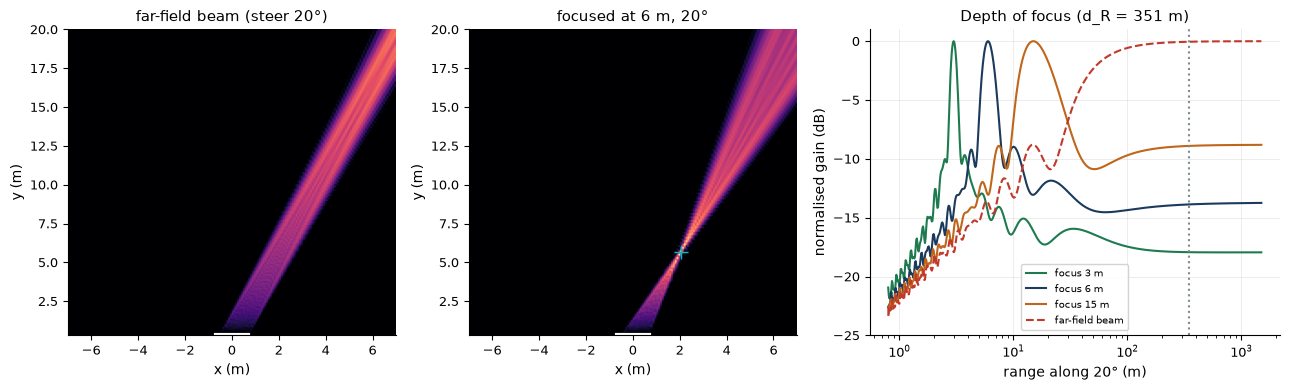

,
aperture D,1.37 m
Rayleigh distance 2D²/λ,351 m
1 m aperture at 3.5 / 30 / 140 GHz,23 m / 200 m / 934 m


In [11]:
def nf_demo(focus_m=6.0, Nel=256, fc_ghz=28.0, angle_deg=20.0):
    fc = fc_ghz * 1e9; lam = C0 / fc; d = lam / 2; D = Nel * d; th = np.deg2rad(angle_deg)
    x = np.linspace(-7, 7, 180); y = np.linspace(0.3, 20, 180); X, Y = np.meshgrid(x, y)
    w_far = np.conj(sixg.farfield_response(Nel, d, fc, th)); w_near = np.conj(sixg.nearfield_response(Nel, d, fc, focus_m, th))
    f, ax = lk.fig((13, 4), 1, 3, gridspec_kw=dict(width_ratios=[1, 1, 1.25]))
    for a, w, t in [(ax[0], w_far, f"far-field beam (steer {angle_deg:g}°)"), (ax[1], w_near, f"focused at {focus_m:g} m, {angle_deg:g}°")]:
        P = sixg.field_map(w, d, fc, X, Y)
        a.imshow(lk.db(P + 1e-6), origin="lower", extent=[x[0], x[-1], y[0], y[-1]], cmap="magma", vmin=-25, vmax=0, aspect="auto")
        a.plot([-D / 2, D / 2], [0.3, 0.3], color="white", lw=3); a.set_xlabel("x (m)"); a.set_ylabel("y (m)"); a.set_title(t); a.grid(False)
    ax[1].plot(focus_m * np.sin(th), focus_m * np.cos(th), "+", color="c", ms=10)
    rr = np.logspace(np.log10(0.8), np.log10(1500), 600)
    for rf, col in [(focus_m / 2, lk.GREEN), (focus_m, lk.NAVY), (focus_m * 2.5, lk.ORANGE)]:
        w = np.conj(sixg.nearfield_response(Nel, d, fc, rf, th))
        ax[2].plot(rr, lk.db([np.abs(sixg.nearfield_response(Nel, d, fc, ri, th) @ w) ** 2 / Nel ** 2 for ri in rr]), color=col, label=f"focus {rf:g} m")
    ax[2].plot(rr, lk.db([np.abs(sixg.nearfield_response(Nel, d, fc, ri, th) @ w_far) ** 2 / Nel ** 2 for ri in rr]), "--", color=lk.RED, label="far-field beam")
    dR = float(sixg.rayleigh_distance(D, fc))
    ax[2].axvline(dR, color=lk.GRAY, ls=":"); ax[2].set_xscale("log"); ax[2].set_ylim(-25, 1); ax[2].legend(fontsize=7.5)
    ax[2].set_xlabel(f"range along {angle_deg:g}° (m)"); ax[2].set_ylabel("normalised gain (dB)"); ax[2].set_title(f"Depth of focus (d_R = {dR:.0f} m)")
    lk.show(f)
    lk.table([["aperture D", f"{D:.2f} m"], ["Rayleigh distance 2D²/λ", f"{dR:.0f} m"],
              ["1 m aperture at 3.5 / 30 / 140 GHz", " / ".join(f"{float(sixg.rayleigh_distance(1.0, f_ * 1e9)):.0f} m" for f_ in (3.5, 30, 140))]], ["", ""])

lk.interact(nf_demo, focus_m=lk.slider(6, 1, 60, 0.5, "focus range (m)"), Nel=lk.choice([64, 128, 256, 512], 256, "elements"),
            fc_ghz=lk.choice([3.5, 28.0, 140.0], 28.0, "carrier (GHz)"), angle_deg=lk.slider(20, -60, 60, 1, "angle (deg)"))

**What you should see.** The far-field beam is a ray that never ends; the focused beam is a spot a few metres long at the focus. The
depth-of-focus panel shows the focused gain falling on both sides of the focus, more sharply for nearer foci, while the far-field
beam only reaches full gain beyond the Rayleigh distance. Two users at the same angle but different ranges can therefore be served
separately: a new spatial dimension. The table reproduces Chapter 25's numbers for a 1 m aperture: 23 m, 200 m and 933 m.

### Try it yourself 4.1
What is the Rayleigh distance (m) of a 0.5 m aperture at 140 GHz?

In [13]:
answer_4_1 = None
lk.check("4.1 Rayleigh distance, 0.5 m at 140 GHz (m)", answer_4_1, float(sixg.rayleigh_distance(0.5, 140e9)), atol=1)

[TODO] 4.1 Rayleigh distance, 0.5 m at 140 GHz (m): not attempted yet: replace the None with your answer

## 5. ISAC: range–Doppler maps and the constellation trade-off

An OFDM base station knows what it sent, so every echo is a radar return: dividing the received grid by the transmitted symbols and
taking an IFFT over subcarriers and an FFT over symbols gives a range–Doppler map. Chapter 25's budget at 28 GHz, 120 kHz, 3300
subcarriers (396 MHz), 256 symbols: $\Delta R = 0.38$ m, $\Delta v = 2.3$ m/s, $\pm300$ m/s, 59 dB of processing gain. Communication
wants *random* symbols (high entropy, Gaussian-like); sensing with a correlation receiver wants *constant-modulus* symbols, because
amplitude fluctuations leave a data-dependent sidelobe floor at about $(\kappa - 1)/N$ ($\kappa = E|x|^4$).

### Interactive: targets and constellation

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

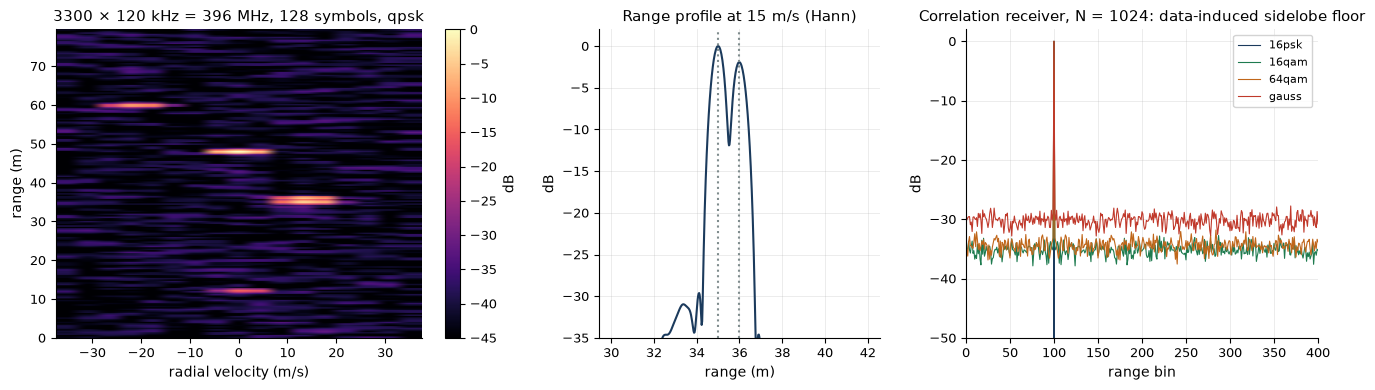

,
range resolution c/(2B),0.38 m
velocity resolution λ/(2NT),4.69 m/s
max unambiguous velocity ±λ/(4T),300 m/s
ISI-free range c·T_cp/2,88 m
processing gain 10log(MN),56 dB
sidelobe floor (κ−1)/N: 16-QAM / 64-QAM,-35.1 / -34.3 dB


In [15]:
def isac_demo(sep_m=1.0, bw_frac=1.0, constellation="qpsk", snr_db=-15.0):
    r = np.random.default_rng(3)
    fc = 28e9; lam = C0 / fc; df = 120e3; M = int(3300 * bw_frac); N = 128
    Ts = (1 / df) * 1.0703
    con = cl.get_constellation(constellation)
    X = con.modulate(cl.random_bits(con.k * M * N, r)).reshape(M, N)
    targets = [(12.0, 1.4, 0.3), (35.0, 15.0, 1.0), (35.0 + sep_m, 15.0, 0.8), (60.0, -22.0, 0.6), (48.0, 0.0, 1.5)]
    Y = sixg.ofdm_radar_echo(X, targets, df, Ts, fc, rng=r, n0=lk.undb(-snr_db))
    RD = sixg.ofdm_radar_map(Y, X)
    P = lk.db(np.abs(RD) ** 2 + 1e-24); P -= P.max()
    dR = C0 / (2 * M * df); dv = lam / (2 * N * Ts)
    rax = np.arange(M) * dR; vax = (np.arange(N) - N / 2) * dv
    rmax = int(80 / dR); vsel = (vax > -40) & (vax < 40)
    fig, ax = lk.fig((13.5, 4), 1, 3, gridspec_kw=dict(width_ratios=[1.3, 0.8, 1]))
    col = np.argmin(np.abs(vax - 15.0))
    Z = (Y / X) * np.hanning(M)[:, None]
    prof = np.abs(np.fft.ifft(np.fft.fftshift(np.fft.fft(Z, axis=1), axes=1)[:, col], 16 * M))
    rr = np.arange(16 * M) * dR / 16; sel = (rr > 30) & (rr < 42)
    ax[1].plot(rr[sel], lk.db(prof[sel] ** 2 / (prof[sel] ** 2).max()), color=lk.NAVY)
    for R_ in (35.0, 35.0 + sep_m):
        ax[1].axvline(R_, color=lk.GRAY, ls=":")
    ax[1].set_ylim(-35, 2); ax[1].set_xlabel("range (m)"); ax[1].set_ylabel("dB"); ax[1].set_title("Range profile at 15 m/s (Hann)")
    ax = [ax[0], ax[2]]
    im = ax[0].imshow(P[:rmax][:, vsel], origin="lower", aspect="auto", cmap="magma", vmin=-45, vmax=0, extent=[vax[vsel][0], vax[vsel][-1], 0, rax[rmax - 1]])
    plt.colorbar(im, ax=ax[0], label="dB"); ax[0].grid(False)
    ax[0].set_xlabel("radial velocity (m/s)"); ax[0].set_ylabel("range (m)"); ax[0].set_title(f"{M} × 120 kHz = {M * df / 1e6:.0f} MHz, {N} symbols, {constellation}")
    Mm = 1024
    for nm, col in [("16psk", lk.NAVY), ("16qam", lk.GREEN), ("64qam", lk.ORANGE), ("gauss", lk.RED)]:
        acc = np.zeros(Mm)
        for _ in range(20):
            Xc = cl.get_constellation(nm).points[r.integers(0, 16 if nm != "64qam" else 64, Mm)] if nm != "gauss" else cn(r, Mm)
            prof = np.abs(np.fft.ifft(Xc * np.exp(-2j * np.pi * np.arange(Mm) * 100 / Mm) * Xc.conj())) ** 2
            acc += prof / prof.max()
        ax[1].plot(lk.db(acc / 20), color=col, lw=0.8, label=nm)
    ax[1].set_xlim(0, 400); ax[1].set_ylim(-50, 2); ax[1].legend(fontsize=8)
    ax[1].set_xlabel("range bin"); ax[1].set_ylabel("dB"); ax[1].set_title("Correlation receiver, N = 1024: data-induced sidelobe floor")
    lk.show(fig)
    kurt = lambda nm: np.mean(np.abs(cl.get_constellation(nm).points) ** 4)
    lk.table([["range resolution c/(2B)", f"{dR:.2f} m"], ["velocity resolution λ/(2NT)", f"{dv:.2f} m/s"], ["max unambiguous velocity ±λ/(4T)", f"{lam / (4 * Ts):.0f} m/s"],
              ["ISI-free range c·T_cp/2", f"{C0 * 0.0703 / df / 2:.0f} m"], ["processing gain 10log(MN)", f"{lk.db(M * N):.0f} dB"],
              ["sidelobe floor (κ−1)/N: 16-QAM / 64-QAM", f"{lk.db((kurt('16qam') - 1) / 1024):.1f} / {lk.db((kurt('64qam') - 1) / 1024):.1f} dB"]], ["", ""])

lk.interact(isac_demo, sep_m=lk.slider(1.0, 0.2, 5.0, 0.1, "separation of the two cars (m)"), bw_frac=lk.choice([0.25, 0.5, 1.0], 1.0, "bandwidth fraction of 396 MHz"),
            constellation=lk.choice(["qpsk", "16qam", "64qam", "256qam"], "qpsk", "data constellation"), snr_db=lk.slider(-15, -40, 10, 1, "per-RE SNR (dB)"))

**What you should see.** Five targets on the map (with 128 symbols here, half the chapter's 256, the velocity resolution is 4.7 m/s
instead of 2.3 m/s). The range profile through the 15 m/s column separates the two cars at 35 and 36 m with 396 MHz (resolution
0.38 m, about 0.75 m with the Hann window); cut the bandwidth to a quarter (99 MHz) and they merge. The map is computed by *dividing* by the data, so here the
constellation does not matter; the right panel shows the other common receiver, a correlation with the transmitted waveform, where
constant-modulus PSK has no data-induced floor (its curve drops off the plot), 16-QAM and 64-QAM floors near −35 and −34 dB, and
Gaussian signalling the highest, near −30 dB:
the deterministic–random trade-off of Chapter 25, where the best communication signal is the worst radar signal.

## 6. RIS: the N² law and the product distance

An optimally phased reconfigurable intelligent surface of $N$ elements of area $A$ acts as an aperture of area $NA$ that captures and
re-radiates: its path gain is $G_tG_r(NA)^2/((4\pi)^2d_1^2d_2^2)$, growing as $N^2$ but falling with the **product** of the two
distances. It equals an unobstructed direct path of length $d$ when $NA = \lambda d_1d_2/d$. Chapter 25: at 28 GHz with $d = 100$ m,
$d_1 = 95.1$ m and $d_2 = 7.07$ m, $N \approx 2500$ (a 27 cm panel); with $b$-bit phase control the coherent gain loses
$20\log_{10}\mathrm{sinc}(2^{-b})$: 0.9 dB for 2 bits, 3.9 dB for 1 bit.

### Interactive: geometry, frequency and phase resolution

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

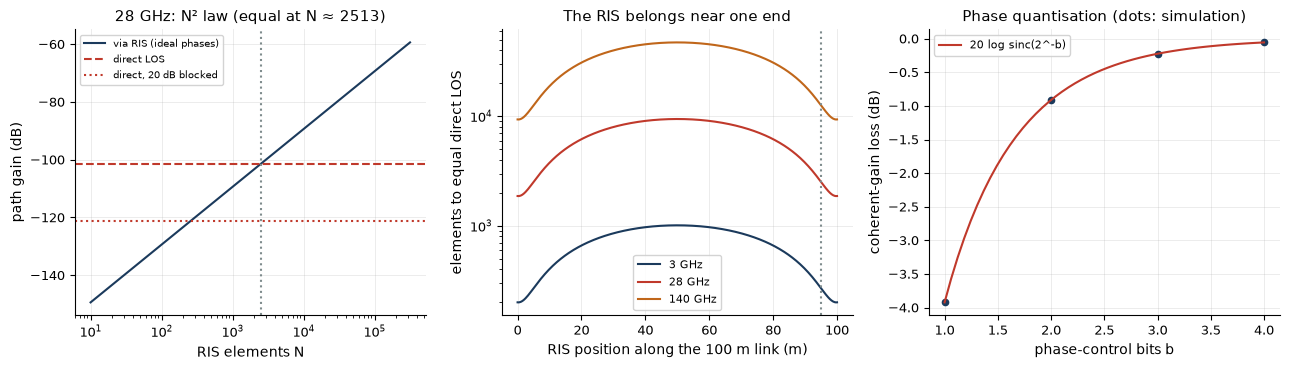

RIS at 28 GHz,
"d1, d2","95.1 m, 7.07 m"
element area (λ/2)²,2.87e-05 m²
N to equal unblocked direct path,2513 (panel 27 cm square)
N to restore the 20 dB-blocked level,251
2-bit phase loss,0.91 dB


In [17]:
def ris_demo(fc_ghz=28.0, ris_x=95.0, ris_off=5.0, bits=2, blockage_db=20.0):
    fc = fc_ghz * 1e9; lam = C0 / fc; A = (lam / 2) ** 2
    d = 100.0; d1 = np.hypot(ris_x, ris_off); d2 = np.hypot(d - ris_x, ris_off)
    Nn = np.logspace(1, 5.5, 200)
    f, ax = lk.fig((13, 3.8), 1, 3)
    g_dir = lk.db(sixg.fspl_gain(d, fc))
    ax[0].semilogx(Nn, lk.db(sixg.ris_gain(Nn, fc, d1, d2)), color=lk.NAVY, label="via RIS (ideal phases)")
    ax[0].axhline(g_dir, color=lk.RED, ls="--", label="direct LOS"); ax[0].axhline(g_dir - blockage_db, color=lk.RED, ls=":", label=f"direct, {blockage_db:g} dB blocked")
    Neq = lam * d1 * d2 / (d * A)
    ax[0].axvline(Neq, color=lk.GRAY, ls=":"); ax[0].set_xlabel("RIS elements N"); ax[0].set_ylabel("path gain (dB)"); ax[0].legend(fontsize=7.5)
    ax[0].set_title(f"{fc_ghz:g} GHz: N² law (equal at N ≈ {Neq:.0f})")
    xr = np.linspace(0, 100, 401)
    for f_, col in [(3e9, lk.NAVY), (28e9, lk.RED), (140e9, lk.ORANGE)]:
        l_ = C0 / f_
        ax[1].semilogy(xr, 4 * np.hypot(xr, ris_off) * np.hypot(d - xr, ris_off) / (l_ * d), color=col, label=f"{f_ / 1e9:g} GHz")
    ax[1].axvline(ris_x, color=lk.GRAY, ls=":"); ax[1].set_xlabel("RIS position along the 100 m link (m)"); ax[1].set_ylabel("elements to equal direct LOS")
    ax[1].legend(fontsize=8); ax[1].set_title("The RIS belongs near one end")
    r = np.random.default_rng(1)
    Ns = 256
    phi = r.uniform(0, 2 * np.pi, (500, Ns))                                   # channel phases the RIS must undo
    for b in (1, 2, 3, 4):
        q = 2 * np.pi / 2 ** b
        res = np.round(-phi / q) * q
        ax[2].plot(b, lk.db(np.mean(np.abs(np.sum(np.exp(1j * (phi + res)), axis=1)) ** 2) / Ns ** 2), "o", color=lk.NAVY)
    bb = np.linspace(1, 4, 50)
    ax[2].plot(bb, 20 * np.log10(np.sinc(2.0 ** -bb)), color=lk.RED, label="20 log sinc(2^-b)")
    ax[2].set_xlabel("phase-control bits b"); ax[2].set_ylabel("coherent-gain loss (dB)"); ax[2].legend(fontsize=8); ax[2].set_title("Phase quantisation (dots: simulation)")
    lk.show(f)
    lk.table([["d1, d2", f"{d1:.1f} m, {d2:.2f} m"], ["element area (λ/2)²", f"{A:.3g} m²"], ["N to equal unblocked direct path", f"{Neq:.0f} (panel {np.sqrt(Neq * A) * 100:.0f} cm square)"],
              [f"N to restore the {blockage_db:g} dB-blocked level", f"{Neq * 10 ** (-blockage_db / 20):.0f}"],
              [f"{bits}-bit phase loss", f"{-20 * np.log10(np.sinc(2.0 ** -bits)):.2f} dB"]], [f"RIS at {fc_ghz:g} GHz", ""])

lk.interact(ris_demo, fc_ghz=lk.choice([3.5, 28.0, 140.0], 28.0, "carrier (GHz)"), ris_x=lk.slider(95, 1, 99, 1, "RIS position along the link (m)"),
            ris_off=lk.slider(5, 1, 30, 1, "RIS offset from the link (m)"), bits=lk.islider(2, 1, 4, 1, "phase bits"),
            blockage_db=lk.slider(20, 0, 40, 1, "direct-path blockage (dB)"))

**What you should see.** The RIS path grows 20 dB per decade of elements and crosses the direct path at about 2500 elements, a 27 cm
panel at 28 GHz, as in Chapter 25 (with 20 dB of blockage, about 250 elements restore the blocked level). The middle panel shows why
an RIS belongs near the transmitter or the receiver: in the middle of the link the product $d_1d_2$ is largest and the required size
explodes. Phase quantisation follows the sinc law: 3.9 dB for 1 bit, 0.9 dB for 2, negligible beyond 3. Try 3.5 GHz: far fewer
elements are needed (about 310) but each is 8 times larger, so the panel is physically much bigger.

### Try it yourself 6.1
How many elements must the 28 GHz RIS have to give the *same* power as the unblocked direct path if it is moved to 50 m along the link
(5 m offset)? Use $N = \lambda d_1 d_2/(dA)$.

In [19]:
answer_6_1 = None
lam28 = C0 / 28e9
lk.check("6.1 RIS elements at mid-link", answer_6_1, lam28 * np.hypot(50, 5) ** 2 / (100 * (lam28 / 2) ** 2), rtol=0.02)

[TODO] 6.1 RIS elements at mid-link: not attempted yet: replace the None with your answer

## Key takeaways
* In the delay–Doppler domain a doubly dispersive channel is a few fixed points; OTFS and AFDM exploit that and collect full diversity.
* An embedded pilot plus guard estimates the whole DD channel at once; fractional Doppler leaks across bins and needs off-grid estimation.
* Large arrays at high frequencies put users in the near field: beams focus on points, and range becomes a spatial dimension.
* OFDM is already a radar: resolution from bandwidth and dwell, and a trade-off between constellation entropy and sidelobe floor.
* An RIS obeys the N² law and the product-distance law: big, and close to one end of the link.

## Going further (hardware: USRP B200 / GNU Radio)
* Use `gnuradio/gr04_ofdm_link.py` with a moving reflector (a person walking) between two B200 antennas and log the channel estimates:
  an FFT over successive packets shows the Doppler of the moving reflector, a first micro-Doppler ISAC experiment.
* With two B200s, emulate an OTFS link in software: modulate with `sixg.otfs_modulate`, transmit as an OFDM frame, and demodulate.

## Exercises
1. **(Warm-up)** Show that `sixg.otfs_matrix(M, N)` is unitary and explain why OTFS needs no extra power for its spreading.
2. **(Core)** Add off-grid Doppler estimation to Section 3 (fit a fractional ν per detected path by a 1-D search) and remove the error floor.
3. **(Core)** Compute the depth of focus analytically (Fresnel approximation) and compare with Section 4.
4. **(Stretch)** Add an RIS to the ISAC scene: a passive surface that creates a second view of the targets, and estimate their positions from both.

In [21]:
lk.summary()

[good] Lab 32 finished in 16.8 s. Self-checks: 0 passed, 0 failed, 3 still to do.